In [19]:
import numpy as np
import opendssdirect as dss
import yadi.dss.model as dss_model
import yadi.dss.qsts as dss_qsts

# `yadi` Time series simulation examples: line and transformer currents

In [20]:
#Load the case3_unbalanced file from PowerModelsDistribution.jl
# cktfile = '/home/sam/Research/yadi/test_cases/secondary_test_network/Master.DSS'
# cktfile = r"../test_cases/{case_file}".format(case_file=case_file)


##### 96 timestep case

cktfile = '/home/sam/Research/evacuationProject/data/OpenDSS Network/v1.1/2016/GSO/urban-suburban/scenarios/base_timeseries/opendss/uhs19_1247/Master_sample1.dss' 

##96 timestep case 

## Use `yadi` to run a time series simulation and construct datasets.

In [21]:
qsts = dss_qsts.DSS_Timeseries(
    redirects=cktfile,
    time_step="15m",
    simulation_steps=24*4,
    simulation_mode="duty",
    simulation_controlmode='static',
    precompile=False
)


In [22]:
qsts.compile_dss()
ratings = qsts.get_conductor_ratings()

DSS Running file: /home/sam/Research/evacuationProject/data/OpenDSS Network/v1.1/2016/GSO/urban-suburban/scenarios/base_timeseries/opendss/uhs19_1247/Master_sample1.dss
DSS Compiled Circuit: substation_uhs19_69


In [23]:
qsts.run()

DSS Running file: /home/sam/Research/evacuationProject/data/OpenDSS Network/v1.1/2016/GSO/urban-suburban/scenarios/base_timeseries/opendss/uhs19_1247/Master_sample1.dss
DSS Compiled Circuit: substation_uhs19_69
QSTS Initialized, Returned:  ['', '', '']


QSTS running...: 100%|██████████| 96/96 [00:40<00:00,  2.36it/s]


In [25]:
#Nodal current injections timeseries
I = qsts.currents_mvts

#Complex power injection timeseries
S = qsts.complex_powers_mvts

#Voltage phasor timeseries
V = qsts.voltages_mvts

#Voltage magnitude per unit (pu) timeseries
Vmags_pu = qsts.vmags_pu_mvts

#Line current timeseries
I_lines = qsts.line_currents_mvts

#Transformer current timeseries
#NOTE: Currently need to fix this, hold off on the transformer currents for now.
#I_xfmrs = qsts.xfmr_currents_mvts

In [26]:
Vmags_pu[:,50]**2

array([1.07933126, 1.06616004, 1.06617225, 1.06617346, 1.0663641 ,
       1.06642706, 1.06612296, 1.06609033, 1.06657493, 1.06640979,
       1.06646909, 1.06626937, 1.06597794, 1.06598855, 1.06587022,
       1.06552886, 1.06508976, 1.06495082, 1.06328838, 1.0640424 ,
       1.06554923, 1.06462085, 1.06382445, 1.06308937, 1.06082222,
       1.05990315, 1.05847831, 1.05704957, 1.05122285, 1.05039021,
       1.04937415, 1.04850511, 1.04783653, 1.04690315, 1.04649417,
       1.04604024, 1.04599855, 1.04551873, 1.04500741, 1.04443572,
       1.04390732, 1.04366805, 1.04318534, 1.04177996, 1.04526297,
       1.04332197, 1.04395309, 1.04369163, 1.03671845, 1.0378141 ,
       1.03534102, 1.03603706, 1.03706009, 1.03350087, 1.03438901,
       1.03469693, 1.03130244, 1.03245418, 1.03377892, 1.03120732,
       1.0320597 , 1.03392456, 1.03218872, 1.03420049, 1.0420194 ,
       1.03994917, 1.04267277, 1.04502221, 1.04316426, 1.04694057,
       1.04983469, 1.05039333, 1.05145459, 1.05226847, 1.05176

In [27]:
Vmags_pu.shape

(96, 4815)

Text(0.5, 1.0, 'Controlmode=time, timestep=15m, simulation_steps=24*4')

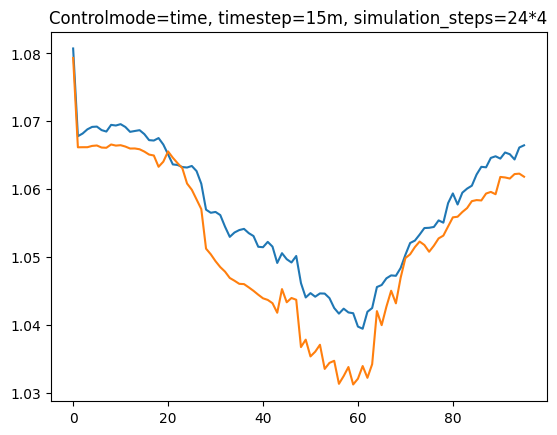

In [28]:
import matplotlib.pyplot as plt
plt.plot(Vmags_pu[:,100]**2)
plt.plot(Vmags_pu[:,50]**2)
plt.title("Controlmode=time, timestep=15m, simulation_steps=24*4")

## Compare different lengths of simulations for different dataset sizes

In [7]:
qsts_24hr = dss_qsts.DSS_Timeseries(
    redirects=cktfile,
    time_step="15m",
    simulation_steps=24*4,
    simulation_mode="duty",
    simulation_controlmode='static',
    precompile=False
)
qsts_24hr.compile_dss()
qsts_24hr.run()
V_24hr = qsts_24hr.vmags_pu_mvts

qsts_48hr = dss_qsts.DSS_Timeseries(
    redirects=cktfile,
    time_step="15m",
    simulation_steps=48*4,
    simulation_mode="duty",
    simulation_controlmode='static',
    precompile=False
)
qsts_48hr.compile_dss()
qsts_48hr.run()
V_48hr = qsts_48hr.vmags_pu_mvts




DSS Running file: /home/sam/Research/evacuationProject/data/OpenDSS Network/v1.0/2016/GSO/urban-suburban/scenarios/base_timeseries/opendss/uhs19_1247/Master_sample1.dss
DSS Compiled Circuit: substation_uhs19_69
DSS Running file: /home/sam/Research/evacuationProject/data/OpenDSS Network/v1.0/2016/GSO/urban-suburban/scenarios/base_timeseries/opendss/uhs19_1247/Master_sample1.dss


/home/sam/Research/yadi/yadi/dss/qsts.py:161: UserWarning: Line sb8_uhs19_1247_36 has no NumConductors attribute, not recording its num_conductors
  warnings.warn("Line {name} has no NumConductors attribute, not recording its num_conductors".format(name=name))
/home/sam/Research/yadi/yadi/dss/qsts.py:161: UserWarning: Line sb8_uhs19_1247_45 has no NumConductors attribute, not recording its num_conductors
  warnings.warn("Line {name} has no NumConductors attribute, not recording its num_conductors".format(name=name))
/home/sam/Research/yadi/yadi/dss/qsts.py:161: UserWarning: Line padswitch(r:udt19283-udt19731)u_82708 has no NumConductors attribute, not recording its num_conductors
  warnings.warn("Line {name} has no NumConductors attribute, not recording its num_conductors".format(name=name))
/home/sam/Research/yadi/yadi/dss/qsts.py:161: UserWarning: Line padswitch(r:udt19320-udt19580)u_82835 has no NumConductors attribute, not recording its num_conductors
  warnings.warn("Line {name} h

DSS Compiled Circuit: substation_uhs19_69
QSTS Initialized, Returned:  ['', '', '']


QSTS running...: 100%|██████████| 96/96 [00:37<00:00,  2.54it/s]


DSS Running file: /home/sam/Research/evacuationProject/data/OpenDSS Network/v1.0/2016/GSO/urban-suburban/scenarios/base_timeseries/opendss/uhs19_1247/Master_sample1.dss
DSS Compiled Circuit: substation_uhs19_69
DSS Running file: /home/sam/Research/evacuationProject/data/OpenDSS Network/v1.0/2016/GSO/urban-suburban/scenarios/base_timeseries/opendss/uhs19_1247/Master_sample1.dss


/home/sam/Research/yadi/yadi/dss/qsts.py:161: UserWarning: Line sb8_uhs19_1247_36 has no NumConductors attribute, not recording its num_conductors
  warnings.warn("Line {name} has no NumConductors attribute, not recording its num_conductors".format(name=name))
/home/sam/Research/yadi/yadi/dss/qsts.py:161: UserWarning: Line sb8_uhs19_1247_45 has no NumConductors attribute, not recording its num_conductors
  warnings.warn("Line {name} has no NumConductors attribute, not recording its num_conductors".format(name=name))
/home/sam/Research/yadi/yadi/dss/qsts.py:161: UserWarning: Line padswitch(r:udt19283-udt19731)u_82708 has no NumConductors attribute, not recording its num_conductors
  warnings.warn("Line {name} has no NumConductors attribute, not recording its num_conductors".format(name=name))
/home/sam/Research/yadi/yadi/dss/qsts.py:161: UserWarning: Line padswitch(r:udt19320-udt19580)u_82835 has no NumConductors attribute, not recording its num_conductors
  warnings.warn("Line {name} h

DSS Compiled Circuit: substation_uhs19_69
QSTS Initialized, Returned:  ['', '', '']


QSTS running...: 100%|██████████| 192/192 [01:13<00:00,  2.60it/s]


In [8]:
V_48hr[0:20,3]

array([1.04452546, 1.03843471, 1.03214619, 1.03240903, 1.03228388,
       1.03237643, 1.03252768, 1.03233844, 1.03236744, 1.03252968,
       1.03235316, 1.03238819, 1.03244845, 1.03231327, 1.03231805,
       1.03238253, 1.03207268, 1.03206032, 1.03207421, 1.03174942])

In [9]:
V_24hr[0:20,3]

array([1.04452546, 1.03843471, 1.03214619, 1.03240903, 1.03228388,
       1.03237643, 1.03252768, 1.03233844, 1.03236744, 1.03252968,
       1.03235316, 1.03238819, 1.03244845, 1.03231327, 1.03231805,
       1.03238253, 1.03207268, 1.03206032, 1.03207421, 1.03174942])

Text(0.5, 1.0, 'Allignment of time series for 48 and 24 hour simulations')

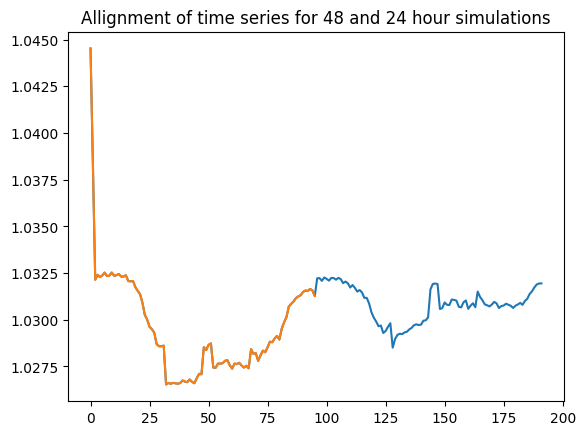

In [12]:
import matplotlib.pyplot as plt
plt.plot(V_48hr[:,3])
plt.plot(V_24hr[:,3])
plt.title("Allignment of time series for 48 and 24 hour simulations")

### Line Current Ratings

In [7]:
ratings

array([900., 900., 900., ..., 295., 295., 295.])

In [8]:
line_data = qsts.get_line_data()
line_data.keys()

dict_keys(['sb8_uhs19_1247_95', 'sb8_uhs19_1247_96', 'sb8_uhs19_1247_71', 'sb8_uhs19_1247_40', 'sb8_uhs19_1247_402', 'sb8_uhs19_1247_404', 'sb8_uhs19_1247_406', 'sb8_uhs19_1247_72', 'sb8_uhs19_1247_401', 'sb8_uhs19_1247_403', 'sb8_uhs19_1247_405', 'l(r:p1ulv40270-udm48725)', 'l(r:udm48725-udt15839lv)', 'l(r:p1ulv43220-udm48726)', 'l(r:p1ulv56991-udm48726)', 'l(r:udm48726-udt15839lv)', 'l(r:p1ulv51387-udt19123lv)', 'l(r:udt15839-udt19123)', 'l(r:p1ulv46241-udt17888lv)', 'l(r:p1ulv56681-udt20292lv)', 'l(r:p1ulv41645-udt16373lv)', 'l(r:p1ulv44888-udt17525lv)', 'l(r:udt16373-udt17525)', 'l(r:udt16373-udt20292)', 'l(r:udt17888-udt20292)', 'l(r:udt15839-udt17888)', 'l(r:udt15839-uhs19_1247)', 'padswitch(r:udt15839-udt19123)u_81699', 'padswitch(r:udt15839-udt19123)u_81700', 'padswitch(r:udt16373-udt17525)u_81691', 'padswitch(r:udt16373-udt17525)u_81692', 'padswitch(r:udt16373-udt20292)u_81693', 'padswitch(r:udt16373-udt20292)u_81694', 'padswitch(r:udt17888-udt20292)u_81695', 'padswitch(r:udt1

In [10]:
print('line_data length:',len(qsts.get_line_data()))
print('names length',len(dss.Lines.AllNames()))
print('I shape:',I_lines.shape)

line_data length: 1749
names length 1755
I shape: (96, 4018)


In [14]:
#Show line data
line_data = qsts.get_line_data()
line_data

{'sb8_uhs19_1247_95': {'BusNames': ['sb8_uhs19_1247_bus_8_2.1.2.3',
   'udt19872-uhs19_1247x.1.2.3'],
  'NumTerminals': 2,
  'NumConductors': 3,
  'NodeOrder': [1, 2, 3, 1, 2, 3],
  'Phases': 3,
  'NormAmps': 900.0,
  'EmergAmps': 600.0},
 'sb8_uhs19_1247_96': {'BusNames': ['sb8_uhs19_1247_bus_8_3.1.2.3',
   'udt15839-uhs19_1247x.1.2.3'],
  'NumTerminals': 2,
  'NumConductors': 3,
  'NodeOrder': [1, 2, 3, 1, 2, 3],
  'Phases': 3,
  'NormAmps': 480.0,
  'EmergAmps': 600.0},
 'sb8_uhs19_1247_71': {'BusNames': ['sb8_uhs19_1247_node_8_7.1.2.3',
   'sb8_uhs19_1247_node_8_8.1.2.3'],
  'NumTerminals': 2,
  'NumConductors': 3,
  'NodeOrder': [1, 2, 3, 1, 2, 3],
  'Phases': 3,
  'NormAmps': 1200.0,
  'EmergAmps': 600.0},
 'sb8_uhs19_1247_40': {'BusNames': ['sb8_uhs19_1247_node_8_5.1.2.3',
   'sb8_uhs19_1247_node_8_6.1.2.3'],
  'NumTerminals': 2,
  'NumConductors': 3,
  'NodeOrder': [1, 2, 3, 1, 2, 3],
  'Phases': 3,
  'NormAmps': 1200.0,
  'EmergAmps': 600.0},
 'sb8_uhs19_1247_402': {'BusNames'

In [35]:
qsts.dss.CktElement.NumConductors()

3

In [28]:
len(line_data)

4730

### Note that the columns correspond to each single phase conductor, so the number of columns is much larger than the length of the line names.

In [25]:
qsts.line_currents_mvts[0,0:100]

array([  289.53991689 -290.0881365j ,   292.30217063 -362.22092479j,
         446.24347613 -459.60063166j,   277.78022288  -85.25345836j,
         289.53992037 -290.08813147j, -1028.08557932+1111.9096703j ,
         446.24347787 -459.60062914j,  -446.24347961 +459.60062663j,
         292.30217237 -362.22092227j,   277.78022287  -85.25342533j,
         277.78022287  -85.2534088j ,  -289.53992037 +290.08813147j,
         446.24347961 -459.60062663j,   289.53991863 -290.08813398j,
        -292.30217411 +362.22091976j,   292.30217411 -362.22091976j,
        -277.78022287  +85.2534088j ,  -277.78022287  +85.25345837j,
          18.81924298  +58.20709128j,     7.93190975  +16.51120866j,
           9.64287723  +16.59077637j,     7.48962605  +13.82065425j,
           7.93813922  +16.53116176j,    14.10598057  +29.52122285j,
          14.10584731  +29.52123905j,    11.49548649  +22.33494229j,
          11.4954656   +22.33494484j,    13.3100669   +30.54446698j,
           8.586896    +21.2265460

## Example 1: Get summary data about all lines and transformers in the network

In [13]:
# Names
line_names = qsts.dss.Lines.AllNames()
xfmr_names = qsts.dss.Transformers.AllNames()

# Summary data
line_data = qsts.get_line_data()
xfmr_data = qsts.get_xfmr_data()

# Ratings 
line_ratings = qsts.get_line_ratings()
xfmr_ratings = qsts.get_xfmr_ratings()

# Show the summar data
print("Line data:")
print(line_data)
print("Transformer data:")
print(xfmr_data)

Line data:
{'sb2_uhs20_1247_68': {'BusNames': ['sb2_uhs20_1247_bus_2_5.1.2.3', 'udt9897-uhs20_1247x.1.2.3'], 'NumTerminals': 2, 'NumConductors': 3, 'NodeOrder': [1, 2, 3, 1, 2, 3], 'Phases': 3, 'NormAmps': 480.0, 'EmergAmps': 600.0}, 'sb2_uhs20_1247_69': {'BusNames': ['sb2_uhs20_1247_bus_2_6.1.2.3', 'udt8894-uhs20_1247x.1.2.3'], 'NumTerminals': 2, 'NumConductors': 3, 'NodeOrder': [1, 2, 3, 1, 2, 3], 'Phases': 3, 'NormAmps': 480.0, 'EmergAmps': 600.0}, 'sb2_uhs20_1247_67': {'BusNames': ['sb2_uhs20_1247_bus_2_4.1.2.3', 'udt5173-uhs20_1247x.1.2.3'], 'NumTerminals': 2, 'NumConductors': 3, 'NodeOrder': [1, 2, 3, 1, 2, 3], 'Phases': 3, 'NormAmps': 480.0, 'EmergAmps': 600.0}, 'sb2_uhs20_1247_364': {'BusNames': ['sb2_uhs20_1247_node_2_18.1.2.3', 'sb2_uhs20_1247_node_2_10.1.2.3'], 'NumTerminals': 2, 'NumConductors': 3, 'NodeOrder': [1, 2, 3, 1, 2, 3], 'Phases': 3, 'NormAmps': 900.0, 'EmergAmps': 600.0}, 'sb2_uhs20_1247_58': {'BusNames': ['sb2_uhs20_1247_node_2_13.1.2.3', 'sb2_uhs20_1247_node_2_

## Example 2: Show datasets of line currents and transformer currents (phasors)

In [26]:
# Line currents -- note, these are the currents flowing w.r.t. from bus -> to bus
I_lines

array([[ 4.046875   -1.609375j  , 12.05037308-13.06241608j,
         9.28688865 -9.83139322j, ...,  5.853119   +9.122498j  ,
         4.034521   +3.358844j  ,  7.735098   +8.335261j  ],
       [ 3.578125   -1.359375j  , 10.59994125-11.99446106j,
         8.24929297 -9.11454014j, ...,  2.844516   +2.571423j  ,
         2.671748   +6.018096j  ,  3.215414   +2.24689j   ],
       [ 3.109375   -1.234375j  ,  9.21878815-10.89163208j,
         6.81491045 -8.39198355j, ...,  2.021965   +1.899365j  ,
         1.888499   +1.793781j  ,  1.773135   +3.485606j  ],
       ...,
       [ 3.015625   -1.328125j  ,  9.64217758-10.64870453j,
         7.55613362 -8.48945713j, ...,  6.851279   +7.562906j  ,
         7.4945     +7.54797j   ,  8.782045   +9.691861j  ],
       [ 3.34375    -1.28125j   , 10.26951981-10.8935318j ,
         7.93068157 -8.01519121j, ...,  6.194966   +8.944237j  ,
         7.644837   +7.873901j  ,  6.498834   +9.895714j  ],
       [ 3.328125   -1.140625j  , 10.28095245 -9.95029449j

## Example 2: Extract static data and current values for a single line or transformer at a single time step.

In [37]:
xfmr_names = dss.Transformers.AllNames()
# Chooose a transformer name for the example
test_xfmr = xfmr_names[0]
print("All available transformer names:")
print(xfmr_names)
print("Transformer name chosen for example:")
print(test_xfmr)

All available transformer names:
['subxfmr', 'trafo1', 'trafo2', 'trafo3', 'trafo4', 'trafo5', 'trafo6', 'trafo7', 'trafo8', 'trafo9', 'trafo10', 'trafo11', 'trafo12']
Transformer name chosen for example:
subxfmr


In [38]:
data = xfmr_data[test_xfmr]
print("Summary data for test xfmr name: {test_xfmr}".format(test_xfmr=test_xfmr))
data

Summary data for test xfmr name: subxfmr


{'isDelta': False,
 'NumWindings': 2,
 'MinTap': 0.9,
 'MaxTap': 1.1,
 'NumTerminals': 2,
 'NumConductors': 4,
 'NodeOrder': [1, 2, 3, 0, 1, 2, 3, 0]}

In [44]:
include_neutral = False # whether or not to include the neutral phase in the extracted currents
xfmr_currents = qsts.get_xfmr_currents(include_neutral=include_neutral) # NOTE: this is the internal function that retrieves currents at the current time step.
c = xfmr_currents[name]
print("Current matrix at transformer named: {x}:".format(x=name))
print(c)

Current matrix at transformer named: subxfmr:
[[  3.34670871 -1.19324221j  -2.34814369 -2.33988113j
   -0.99856502 +3.53312334j]
 [-10.28095807 +9.95028822j  11.10210645 +2.32684566j
   -3.90039636-12.62357287j]]


In [45]:

# Get from-> to and to->from currents.
c_from = c[0,:] # The first row is the from->to currents
c_to = c[1,:] # The second row is the to->from currents
print("From->to currents:")
print(c_from)
print("To->from currents:")
print(c_to)

From->to currents:
[ 3.34670871-1.19324221j -2.34814369-2.33988113j -0.99856502+3.53312334j]
To->from currents:
[-10.28095807 +9.95028822j  11.10210645 +2.32684566j
  -3.90039636-12.62357287j]
